# Análisis y procesamiento de señales

## Trabajo práctico N°2

### Ferreyra Valentina

El objetivo de este trabajo práctico es simular el funcionamiento de un ADC y analizar qué tan bien puede digitalizarse una señal en presencia de ruido y cuantización. A partir del trabajo, se estudia cómo el nivel de ruido y la resolución del ADC influyen en la representación digital de la señal.

#### Inciso A

In [170]:
import numpy as np
import matplotlib.pyplot as plt

In [171]:
N = 1000
fs = 1000
vmax = np.sqrt(2) 
dc = 0
ph = 0
ff = (fs/N)

La senoide debía tener varianza o potencia unitaria, es decir, $P_s = 1$. Para una senoide de media cero, la potencia se expresa como $P_s = \frac{A^2}{2}$, por lo que al imponer $\frac{A^2}{2} = 1$ y al despejar la amplitud se obtiene $A = \sqrt{2}$. Por esta razón se eligió $V_{max} = \sqrt{2}$, lo que garantiza que la potencia de la senoide sea igual a 1.

La frecuencia de la senoide se eligió como $f_0 = \frac{f_s}{N}$, valor que coincide con la resolución frecuencial de la FFT, definida como $\Delta f = \frac{f_s}{N}$. Para una frecuencia de muestreo de $f_s = 1000\ \text{Hz}$ y una cantidad de muestras $N = 1000$, se obtiene $\Delta f = 1\ \text{Hz}$ y, por lo tanto, $f_0 = 1\ \text{Hz}$. De esta manera, la frecuencia de la senoide coincide exactamente con uno de los bins de la FFT, permitiendo que su energía quede concentrada en una única componente frecuencial.

In [172]:
B = 4
Vfs = 2
qq = (2*Vfs) / (2**B)

$B$ es la cantidad de bits del ADC. Un ADC de $B$ bits puede representar $2^B$ niveles distintos. Cuantos más bits tiene el ADC, más niveles tiene disponibles y con mayor precisión puede representar la amplitud de la señal. $V_{fs}$ es la tensión de fondo de escala del ADC, que según la consigna es igual a $2\ \text{V}$. Como el rango del ADC es de $\pm V_{fs}$, puede trabajar entre $-2\ \text{V}$ y $+2\ \text{V}$, dando un rango total de $4\ \text{V}$. Este valor se utiliza para calcular el paso de cuantización, dado por $q = \frac{2V_{fs}}{2^B}$. Cuanto menor sea $q$, más próximos se encuentran los niveles de cuantización y mejor puede aproximarse la señal original.

In [173]:
kn = 1
Pq = (qq)**2/12 
Pn = kn*Pq 

$K_n$ indica qué tan grande es la potencia del ruido que se agrega a la señal respecto de la potencia del ruido de cuantización. Según la consigna, $K_n = 1$, por lo que se cumple que $P_n = P_q$. Esto significa que la potencia del ruido gaussiano agregado a la senoide es igual a la potencia teórica del ruido de cuantización.

In [174]:
def mi_funcion_sen():

    n = np.arange(N) / fs

    xx = dc + vmax * np.sin(2*np.pi*ff*n + ph)
    
    return (n,xx)

n,xx = mi_funcion_sen()

# Declaro el ruido
ruido = np.random.normal (0,np.sqrt(Pn),N)

# Senoide + Ruido
xx_ruido = xx + ruido

Se genera la senoide y luego una secuencia de $N$ muestras de ruido gaussiano de media cero y desviación estándar $\sqrt{P_n}$.

Finalmente, el ruido se suma a la senoide para obtener la señal que se ingresa al ADC

In [175]:
xx_q = np.round(xx_ruido / qq) * qq 
nq = xx_q - xx_ruido 

Luego se realiza la cuantización de la señal que ingresa al ADC. Para ello, cada muestra de $s_R$ se divide por el paso de cuantización $q$, se redondea al nivel entero más cercano y finalmente se vuelve a multiplicar por $q$, obteniendo así la señal cuantizada $s_Q$. De esta manera, cada muestra queda limitada a uno de los niveles que puede representar el ADC. Luego se calcula el error de cuantización como $n_q = s_Q - s_R$, que representa cuánto se modifica cada muestra debido exclusivamente al proceso de cuantización.

A continuación se calculó la FFT de la senoide original, de la señal con ruido y de la señal cuantizada, con el objetivo de comparar el comportamiento de las tres señales en el dominio de la frecuencia.

In [176]:
frec = np.arange(N//2) * fs/N

xx_fft = 1/N * np.fft.fft(xx)

XX_mod = np.abs(xx_fft)

espectro = (XX_mod)**2
dens_espc = 10*np.log10(2*(espectro[:N//2]))


In [177]:
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = (XX_ruido_mod)**2
dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [178]:
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = (XX_q_mod)**2
dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]+1e-20))

A partir de las $N$ muestras de la señal se obtiene su representación frecuencial y, como para una señal real el espectro presenta simetría entre frecuencias positivas y negativas, se utilizan solamente los primeros $N/2$ valores, correspondientes al intervalo entre $0$ y $f_s/2$. 

Como la FFT devuelve valores complejos, se calcula su módulo para obtener la magnitud de cada componente frecuencial y luego se eleva al cuadrado para obtener una magnitud asociada a su potencia. Finalmente, la potencia se expresa en decibeles mediante $10\log_{10}(P)$, lo que permite visualizar y comparar con mayor claridad componentes que presentan potencias muy diferentes, como la senoide y el piso de ruido.

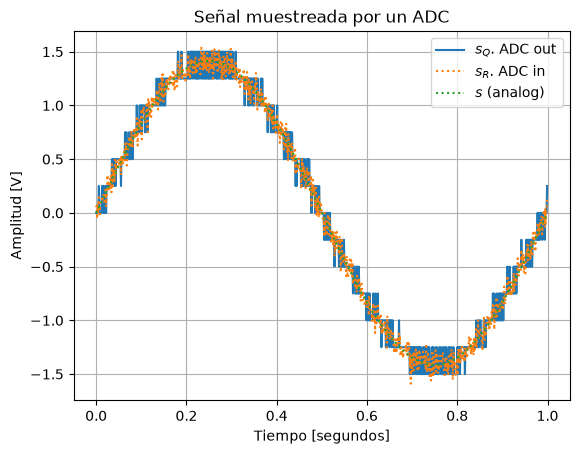

In [179]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$ (analog)')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()
plt.show()

En este gráfico se observan la señal senoidal ideal, la señal senoidal con el ruido agregado y la señal cuantizada a la salida del ADC. La señal con ruido presenta pequeñas variaciones alrededor de la senoide original debido a la perturbación gaussiana añadida. Por otro lado, la señal cuantizada sigue la forma general de la señal de entrada, pero solo puede tomar determinados niveles de amplitud definidos por el paso de cuantización. Por este motivo, la salida del ADC no coincide exactamente con la señal de entrada y presenta un comportamiento escalonado, asociado al error de cuantización.
Con $B = 4$, el paso de cuantización es relativamente grande, entonces la salidad del ADC no reproduce exactamente todos los valores de entrada.

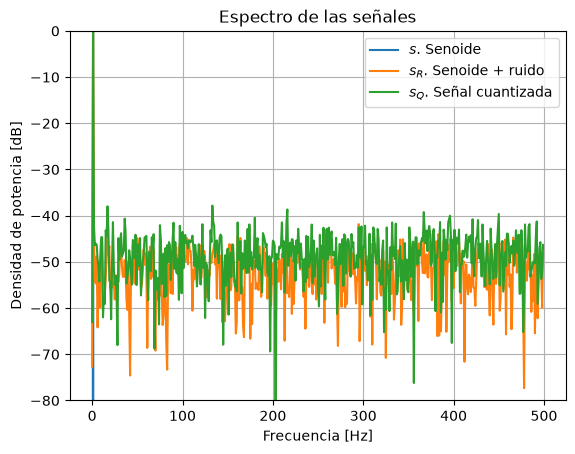

In [180]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-80, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

En el gráfico se representa el espectro de la senoide ideal $s$, la señal con ruido $s_R$ y la señal cuantizada $s_Q$. Se observa un pico aproximadamente en $f_0 = 1\ \text{Hz}$, correspondiente a la frecuencia de la senoide, cuya potencia se encuentra cercana a $0\ \text{dB}$. Mientras que en $s_R$ se observa un piso de ruido distribuido a lo largo del espectro debido al ruido gaussiano agregado. En la señal cuantizada $s_Q$ también se observa un piso de ruido, asociado tanto al ruido presente en la entrada como al error introducido durante la cuantización.

El piso de ruido aparece aproximadamente alrededor de $-50\ \text{dB}$ porque la potencia total del ruido no se concentra en una única frecuencia, sino que se distribuye entre muchos bins de la FFT. En este caso, como $k_n = 1$, la potencia del ruido agregado es igual a la potencia teórica del ruido de cuantización, $P_n = P_q$. Al repartirse esta potencia entre las distintas componentes frecuenciales, la potencia asociada a cada bin resulta mucho menor y, al expresarla en decibeles mediante $10\log_{10}(P)$, se obtienen valores cercanos a $-50\ \text{dB}$. Debido al carácter aleatorio del ruido gaussiano, estos valores no son idénticos en todos los bins, sino que fluctúan alrededor de un nivel promedio denominado piso de ruido.

Fuera de la frecuencia principal de la senoide, su potencia teórica debería ser nula. Sin embargo, debido a la precisión numérica finita con la que trabaja la computadora, la FFT puede devolver valores extremadamente pequeños en lugar de ceros exactos. Al convertir estos valores a decibeles mediante $10\log_{10}(P)$, aparecen valores muy negativos, del orden de $-300$ o $-350\ \text{dB}$. Estos valores no representan ruido real de la señal, sino errores numéricos asociados al cálculo. Por esta razón, para facilitar la visualización del pico de la senoide y de los pisos de ruido, se limitó el eje vertical del gráfico al intervalo entre $-80$ y $0\ \text{dB}$.

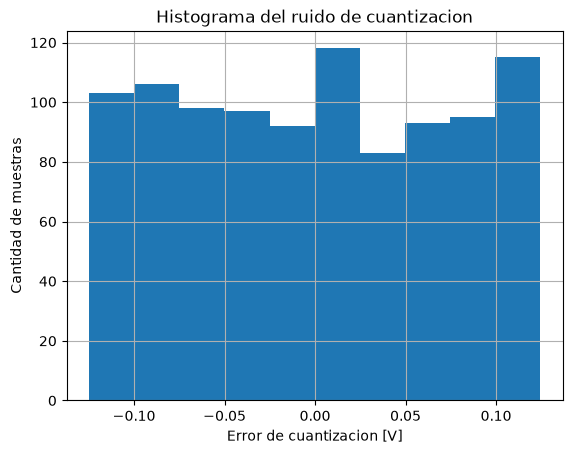

In [181]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Histograma del ruido de cuantizacion')

plt.grid()
plt.show()

Finalmente, se realizó un histograma del error de cuantización $n_q = s_Q - s_R$ con el objetivo de analizar cómo se distribuyen los errores introducidos por el ADC. Como el paso de cuantización es $q = 0.25\ \text{V}$, teóricamente el error de cuantización debería encontrarse aproximadamente dentro del intervalo $-\frac{q}{2} \leq n_q \leq \frac{q}{2}$, es decir, entre $-0.125\ \text{V}$ y $+0.125\ \text{V}$. En el histograma se observa que los valores se distribuyen de manera aproximadamente uniforme dentro de dicho intervalo, lo cual resulta consistente con el modelo utilizado para el ruido de cuantización y con la expresión teórica $P_q = \frac{q^2}{12}$.

#### Inciso B

En el inciso B se analiza cómo cambia el comportamiento del ADC al modificar la cantidad de bits y el valor de $K_n$. De esta forma, se estudia cómo influyen la resolución del ADC y el nivel de ruido agregado sobre la representación digital de la señal, comparando los resultados con los obtenidos en el inciso A.

Se repite el mismo procedimiento utilizado en el inciso A para obtener las representaciones en frecuencia. La FFT de la senoide ideal se mantiene sin cambios, ya que la señal $s$ es la misma, pero que se vuelven a calcular las FFT de la señal con ruido $s_R$ y de la señal cuantizada $s_Q$, debido a que al modificar la cantidad de bits también cambian el paso de cuantización y las potencias de ruido asociadas.

In [182]:
B = 8
kn = 1

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [183]:
frec = np.arange(N//2)*fs/N


# FFT senoide

xx_fft = 1/N * np.fft.fft(xx)

XX_mod = np.abs(xx_fft)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*(espectro[:N//2]))


# FFT senoide + ruido

xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))


# FFT señal cuantizada

xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

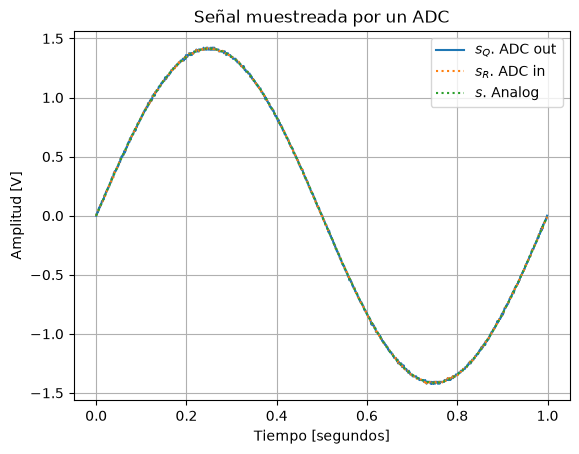

In [184]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

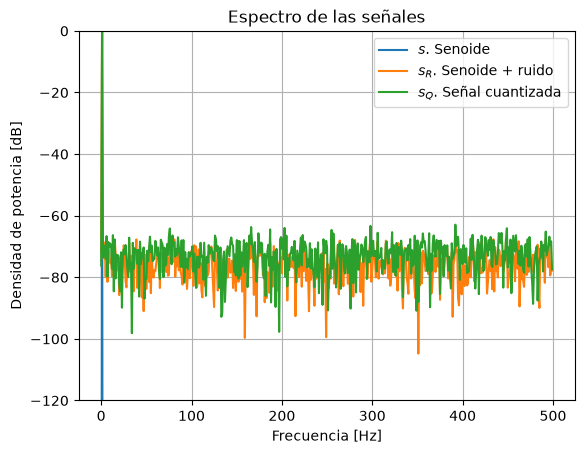

In [185]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-120, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

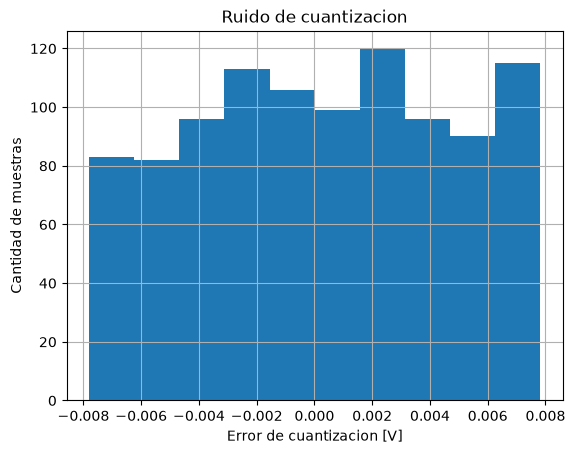

In [186]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [187]:
B = 16
kn = 1

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [188]:
# FFT senoide
xx_fft = 1/N * np.fft.fft(xx)

XX_mod = np.abs(xx_fft)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*(espectro[:N//2]))

In [189]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [190]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

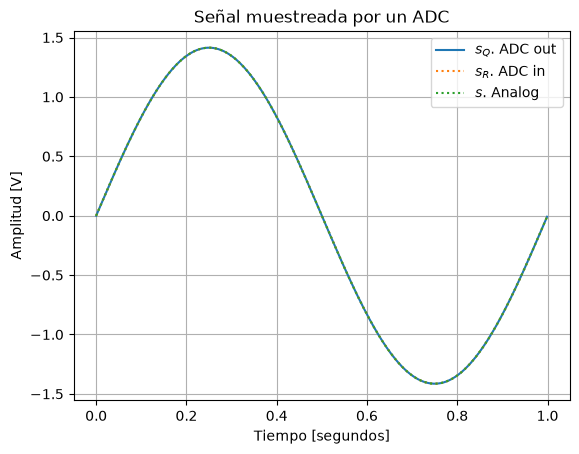

In [191]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

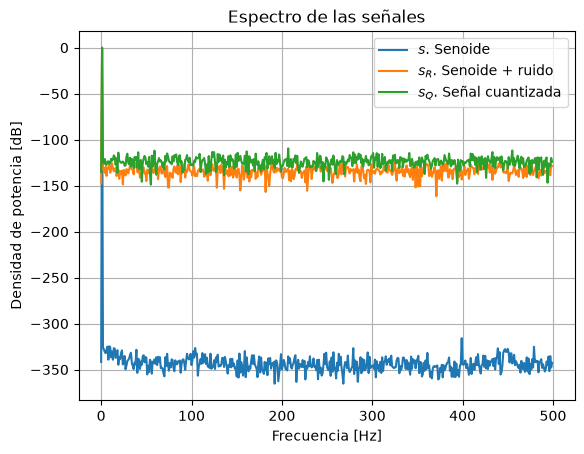

In [233]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')

plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

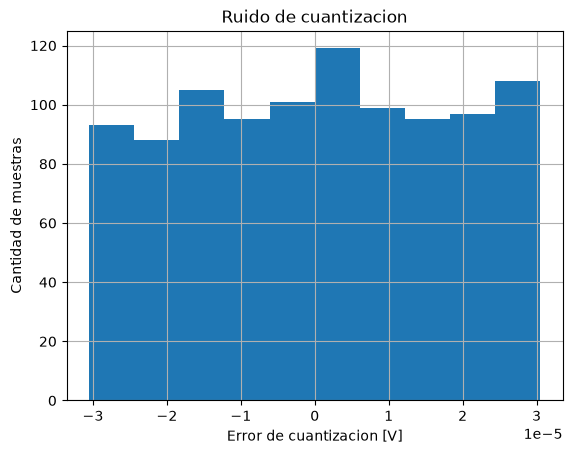

In [193]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [194]:
B = 4
kn = 10

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [195]:
# FFT senoide
xx_fft = 1/N * np.fft.fft(xx)

XX_mod = np.abs(xx_fft)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*(espectro[:N//2]))

In [196]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [197]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

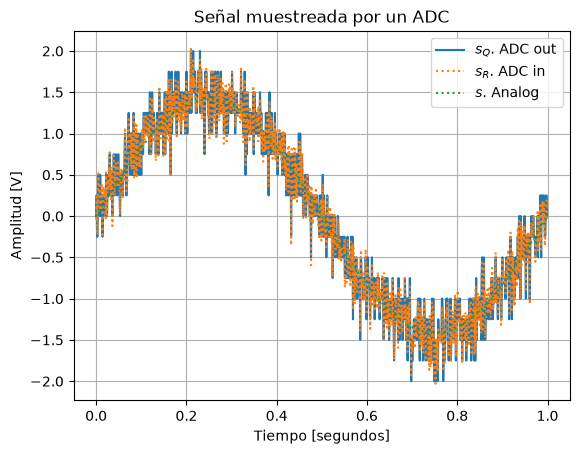

In [198]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

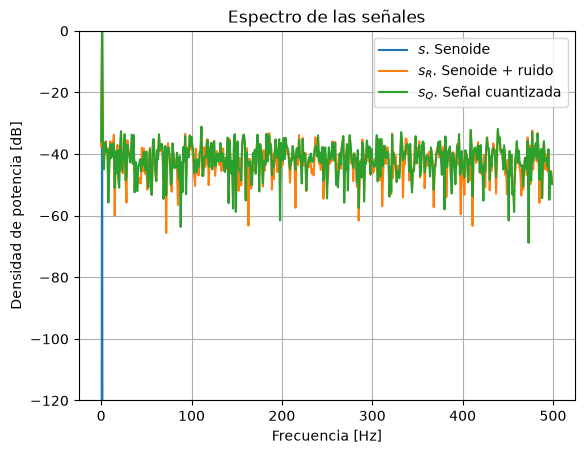

In [199]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-120, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

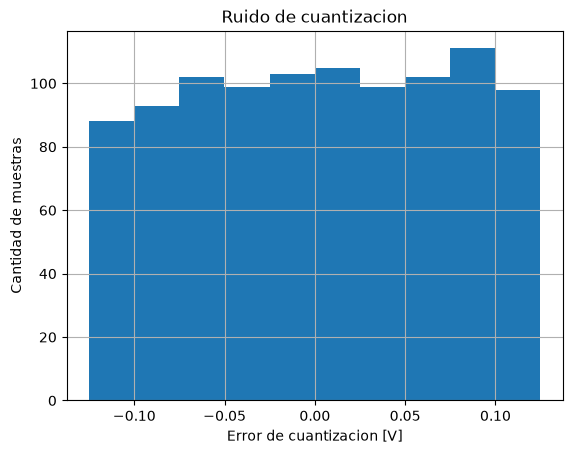

In [200]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [201]:
B = 8
kn = 10

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [202]:
# FFT senoide
xx_fft = 1/N * np.fft.fft(xx)

XX_mod = np.abs(xx_fft)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*(espectro[:N//2]))

In [203]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [204]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

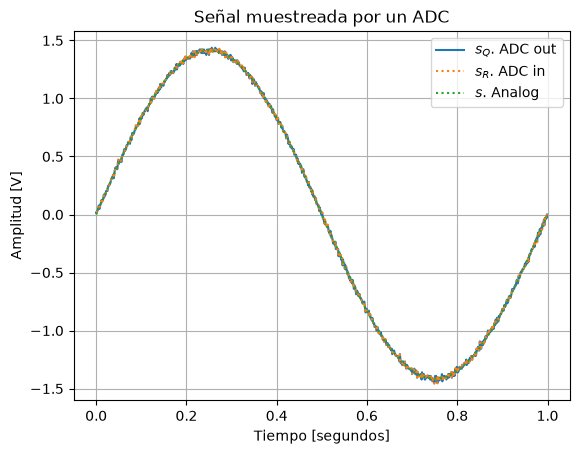

In [205]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

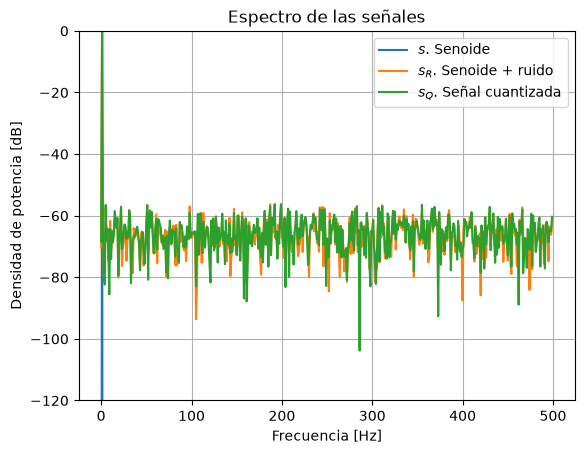

In [206]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-120, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

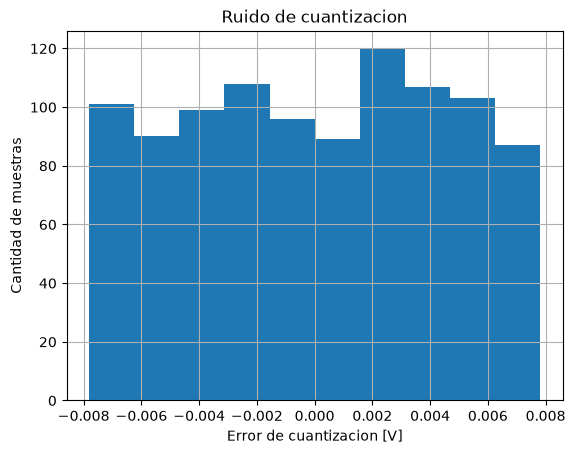

In [207]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [208]:
B = 16
kn = 10

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [209]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [210]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

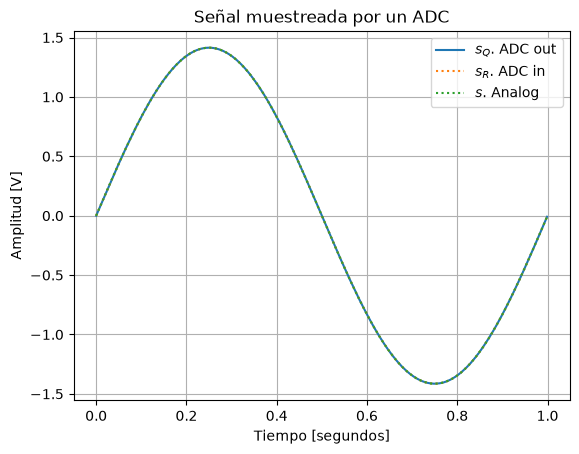

In [211]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

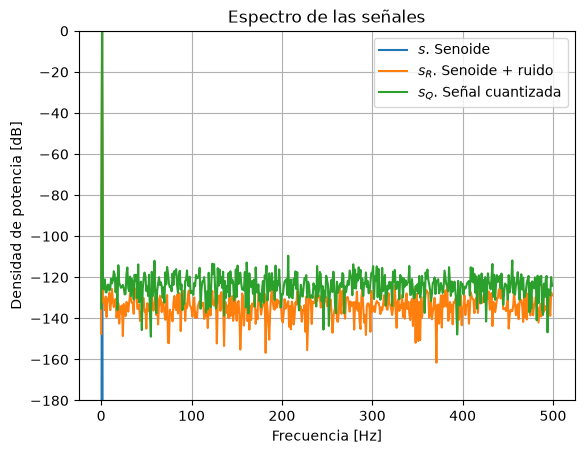

In [235]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-180, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

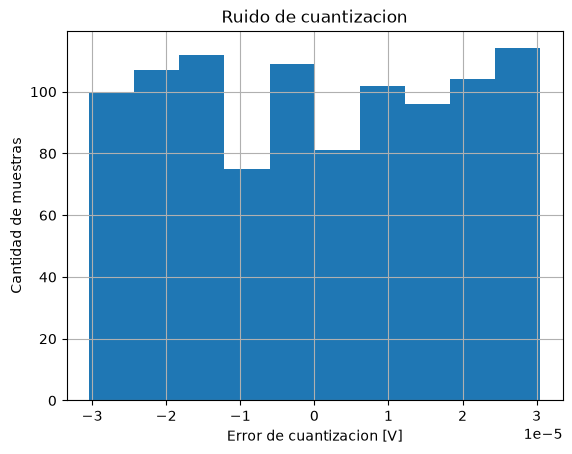

In [213]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [214]:
B = 4
kn = 1/10

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [215]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [216]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

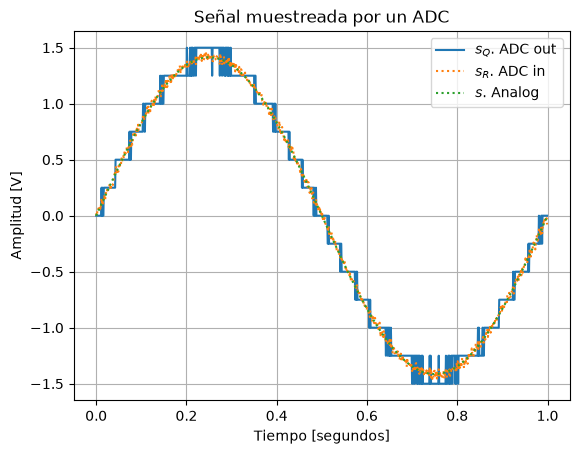

In [217]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

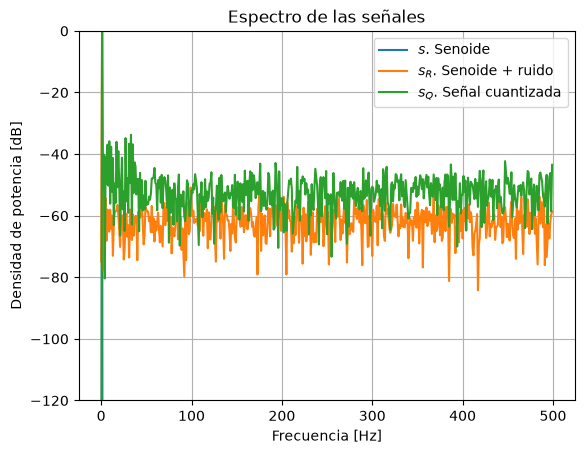

In [218]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-120, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

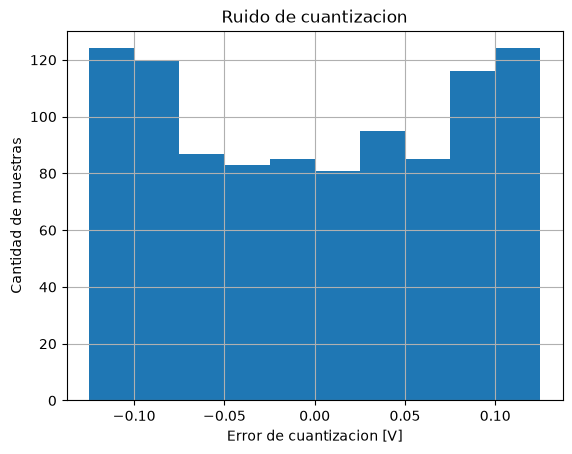

In [219]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [220]:
B = 8
kn = 1/10

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [221]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [222]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

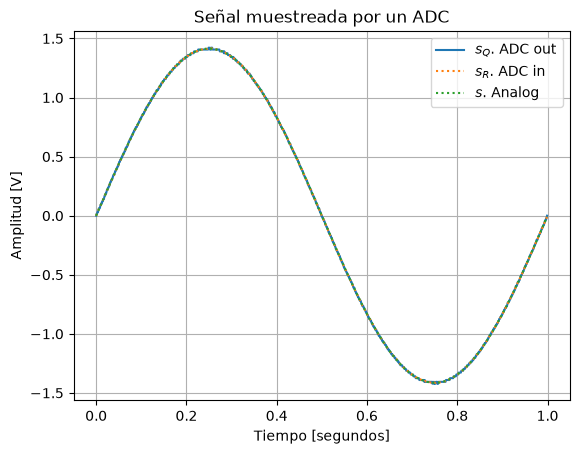

In [223]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

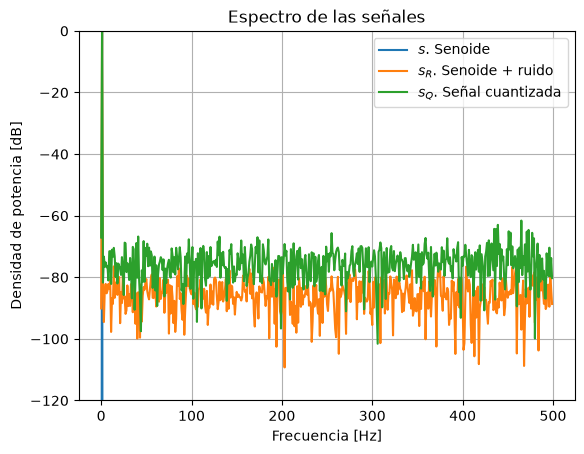

In [224]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.ylim(-120, 0)
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

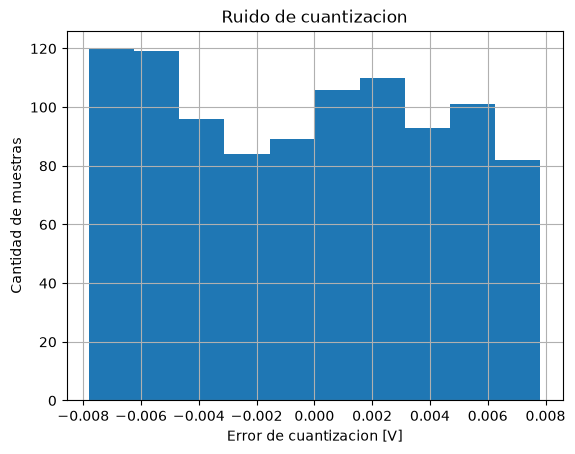

In [225]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

In [226]:
B = 16
kn = 1/10

qq = (2*Vfs)/(2**B)
Pq = qq**2/12
Pn = kn*Pq

ruido = np.random.normal(0, np.sqrt(Pn), N)
xx_ruido = xx + ruido

xx_q = np.round(xx_ruido/qq)*qq
nq = xx_q - xx_ruido

In [227]:
# FFT senoide + ruido
xx_ruido_fft = 1/N * np.fft.fft(xx_ruido)

XX_ruido_mod = np.abs(xx_ruido_fft)

espectro_ruido = XX_ruido_mod**2

dens_espc_ruido = 10*np.log10(2*(espectro_ruido[:N//2]))

In [228]:
# FFT señal cuantizada
xx_q_fft = 1/N * np.fft.fft(xx_q)

XX_q_mod = np.abs(xx_q_fft)

espectro_q = XX_q_mod**2

dens_espc_q = 10*np.log10(2*(espectro_q[:N//2]) + 1e-20)

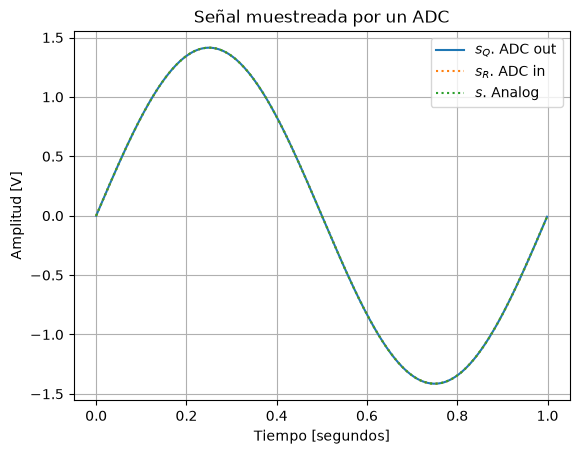

In [229]:
plt.figure()

plt.plot(n, xx_q, label='$s_Q$. ADC out')
plt.plot(n, xx_ruido, ':', label='$s_R$. ADC in')
plt.plot(n, xx, ':', label='$s$. Analog')

plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title('Señal muestreada por un ADC')

plt.grid()
plt.legend()

plt.show()

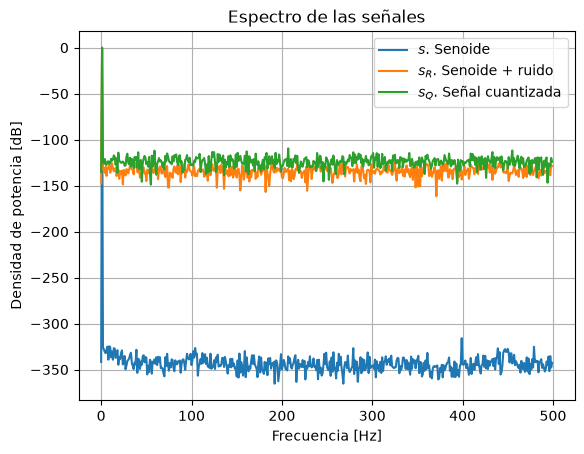

In [236]:
plt.figure()

plt.plot(frec, dens_espc, label='$s$. Senoide')
plt.plot(frec, dens_espc_ruido, label='$s_R$. Senoide + ruido')
plt.plot(frec, dens_espc_q, label='$s_Q$. Señal cuantizada')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title('Espectro de las señales')

plt.grid()
plt.legend()

plt.show()

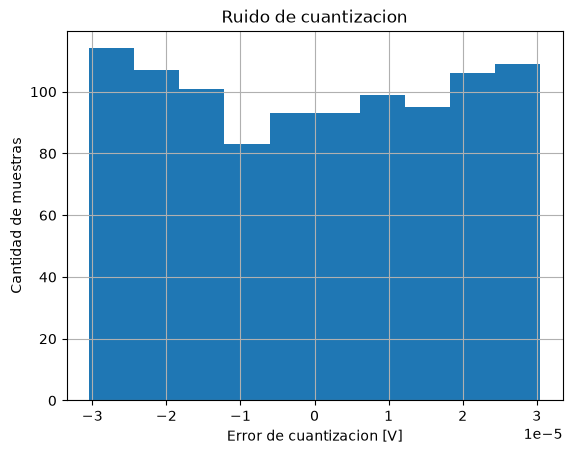

In [231]:
plt.figure()

plt.hist(nq, bins=10)

plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Cantidad de muestras')
plt.title('Ruido de cuantizacion')

plt.grid()

plt.show()

En términos generales, al aumentar la cantidad de bits $B$ disminuye el paso de cuantización $q$ y, en consecuencia, también disminuye la potencia del ruido de cuantización $P_q$, permitiendo que la señal digital represente con mayor precisión a la señal de entrada. Al disminuir $B$ ocurre lo contrario, aumentando el error introducido por la cuantización. 

Por otro lado, $K_n$ determina la potencia del ruido gaussiano agregado mediante $P_n = K_nP_q$: al aumentar $K_n$ aumenta el piso de ruido analógico, mientras que al disminuirlo se obtiene una señal más limpia. Para $K_n = 1$ se cumple $P_n = P_q$, para $K_n < 1$ el ruido de cuantización tiene mayor importancia relativa y para $K_n > 1$ predomina el ruido presente a la entrada del ADC. 

Al analizar ambos parámetros en conjunto, si aumenta $B$ y disminuye $K_n$, disminuyen tanto el error de cuantización como el ruido agregado, obteniéndose una mejor representación de la señal; en cambio, si disminuye $B$ y aumenta $K_n$, ambos efectos perjudican la calidad de la digitalización. Cuando $B$ y $K_n$ aumentan o disminuyen simultáneamente, sus efectos pueden oponerse, ya que aumentar $B$ reduce $q$ y $P_q$, mientras que aumentar $K_n$ incrementa la potencia del ruido agregado.

#### Bonus

Para analizar la relación entre la cantidad de bits del ADC y la relación señal-ruido se parte de la expresión $\mathrm{SNR}_q = 10\log_{10}\left(\frac{P_s}{P_q}\right)$, donde $P_s$ es la potencia de la señal y $P_q$ la potencia del ruido de cuantización. Como en este trabajo se utiliza una senoide de potencia unitaria, $P_s = 1$, y además $P_q = \frac{q^2}{12}$, con $q = \frac{2V_{fs}}{2^B}$, se observa que al aumentar la cantidad de bits disminuye el paso de cuantización y, por lo tanto, también disminuye la potencia del ruido de cuantización. Cada bit adicional divide $q$ por 2, lo que reduce $P_q$ por un factor 4. En escala logarítmica, esto produce un aumento aproximado de $10\log_{10}(4) = 6.02\ \text{dB}$ en la SNR. Entonces, cada bit adicional de resolución del ADC mejora la relación señal-ruido de cuantización aproximadamente en $6\ \text{dB}$.

### Conclusión

A lo largo del trabajo se simuló el comportamiento de un ADC al digitalizar una señal senoidal contaminada con ruido, analizando el efecto de la cuantización y de la resolución del conversor. Se observó que al aumentar la cantidad de bits disminuye el paso de cuantización, se reduce el error introducido por el ADC y la señal digital representa con mayor precisión a la señal de entrada. También se verificó que el parámetro $K_n$ controla la potencia del ruido gaussiano agregado, modificando el piso de ruido del espectro: valores mayores de $K_n$ producen una señal más contaminada, mientras que valores menores generan una señal más limpia. Los histogramas del error de cuantización mostraron un comportamiento aproximadamente uniforme dentro del intervalo $\left[-\frac{q}{2},\frac{q}{2}\right]$, que tiene sentido según con el modelo utilizado.